# 03 — 2PACF: IRAC-Footprint Sample

This notebook computes and inspects the two-point angular correlation function
for the **IRAC-footprint (masked)** sample — the primary science sample of this
analysis. It mirrors what `scripts/run_2pacf.py --sample edf_s_irac_footprint`
does, but exposes each step for inspection.

**Estimator**: Landy-Szalay (1993)
$$w(\theta) = \frac{DD - 2\,DR + RR}{RR}$$

**Bins**: 15 log-spaced, $0.009°$–$3.3°$ (edge-effect limit $\approx L_{\rm min}/3$)  
**Randoms**: $100\times N_{\rm gal}$, uniform and masked

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import matplotlib.pyplot as plt

from src.config import cfg, resolve_path
from src.catalog import load_fits_catalog, filter_radec_range, apply_sky_mask, get_radec
from src.randoms import generate_random_catalog
from src.correlation import compute_2pacf, CorrelationResult
from src.plotting import plot_2pacf, plot_sky_distribution, plot_data_vs_randoms_density

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

SAMPLE = "edf_s_irac_footprint"

## 1. Load and filter the galaxy catalog

In [2]:
import healsparse

sample_cfg  = cfg["samples"][SAMPLE]
cols        = cfg["columns"]
field_name  = sample_cfg["field"]          # e.g. "edf_s"
irac_filter = sample_cfg.get("irac_filter", "none")
survey      = cfg["fields"][field_name]

table = load_fits_catalog(str(resolve_path(cfg["paths"]["raw_catalog"])))
print(f"Full catalog: {len(table):,} rows")

# IRAC filter
if irac_filter == "footprint":
    sel = np.asarray(table[cols["irac_footprint"]], dtype=bool)
    table = table[sel]
elif irac_filter == "detected":
    sel = np.asarray(table[cols["irac_detected"]], dtype=bool)
    table = table[sel]
elif irac_filter == "no_footprint":
    sel = ~np.asarray(table[cols["irac_footprint"]], dtype=bool)
    table = table[sel]
print(f"After IRAC filter ({irac_filter}): {len(table):,} rows")

# Sky cut
table = filter_radec_range(
    table,
    ra_min=survey["ra_min"],  ra_max=survey["ra_max"],
    dec_min=survey["dec_min"], dec_max=survey["dec_max"],
    ra_col=cols["ra"], dec_col=cols["dec"],
)
print(f"After sky cut : {len(table):,}")

# HealSparse mask (if defined for this field)
mask_rel = survey.get("mask_healsparse")
if sample_cfg.get("apply_mask", False) and mask_rel:
    mask_path = str(resolve_path(mask_rel))
    mask_map  = healsparse.HealSparseMap.read(mask_path)
    nside     = mask_map.nside_sparse
    table     = apply_sky_mask(table, mask_map, nside, ra_col=cols["ra"], dec_col=cols["dec"])
    print(f"After mask    : {len(table):,}")
else:
    print("No mask applied (field has no mask or apply_mask=false)")

ra, dec = get_radec(table, ra_col=cols["ra"], dec_col=cols["dec"])

Loaded catalog: /home/k3vinpaul/LRDs/data/raw/LRD_MarIRAC.fits
  Objects : 3,341
  Columns : ['ID', 'RA', 'DEC', 'z', 'z_err', 'MUV', 'MUV_err', 'beta_UV', 'beta_UV_err', 'beta_opt', 'beta_opt_err', 'IRAC-detected', 'IRAC-footprint']
Full catalog: 3,341 rows
After IRAC filter (footprint): 1,509 rows
Sky cut [55.0,67.5] × [-52.5,-44.5]: 1,199 / 1,509 objects kept
After sky cut : 1,199
Mask applied: 1,028 / 1,199 objects kept (85.7%)
After mask    : 1,028
  RA  range : 56.0159 – 66.4193 deg
  Dec range : -51.1821 – -45.6736 deg


## 2. Load or generate random catalog

In [3]:
from astropy.table import Table

rand_path = resolve_path(f"data/processed/randoms_{SAMPLE}.fits")

if rand_path.exists():
    rand      = Table.read(str(rand_path))
    ra_rand   = np.asarray(rand["RA"])
    dec_rand  = np.asarray(rand["DEC"])
    print(f"Loaded cached randoms: {len(ra_rand):,}  ({rand_path.name})")
else:
    print("Generating randoms (this takes a minute) …")
    factor    = cfg["randoms"]["n_randoms_factor"]
    rand_table = generate_random_catalog(
        mask_map=mask_map, nside=nside,
        n_randoms=factor * len(ra),
        ra_min=survey["ra_min"],  ra_max=survey["ra_max"],
        dec_min=survey["dec_min"], dec_max=survey["dec_max"],
        batch_factor=cfg["randoms"]["batch_factor"],
        seed=cfg["randoms"]["seed"],
    )
    rand_table.write(str(rand_path), format="fits", overwrite=True)
    ra_rand  = np.asarray(rand_table["RA"])
    dec_rand = np.asarray(rand_table["DEC"])
    print(f"Generated {len(ra_rand):,} randoms → {rand_path}")

print(f"Random-to-data ratio: {len(ra_rand)/len(ra):.1f}×")

Loaded cached randoms: 102,800  (randoms_edf_s_irac_footprint.fits)
Random-to-data ratio: 100.0×


## 3. Sky distribution: data vs randoms

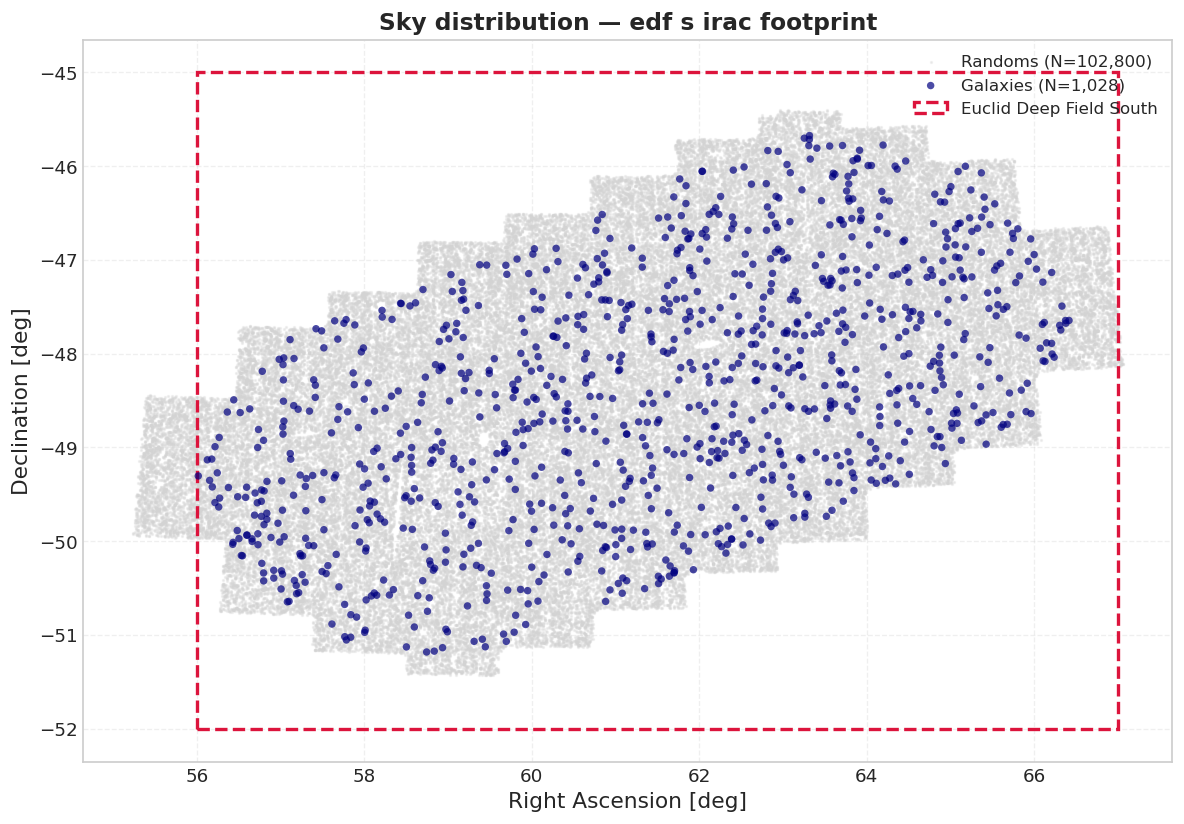

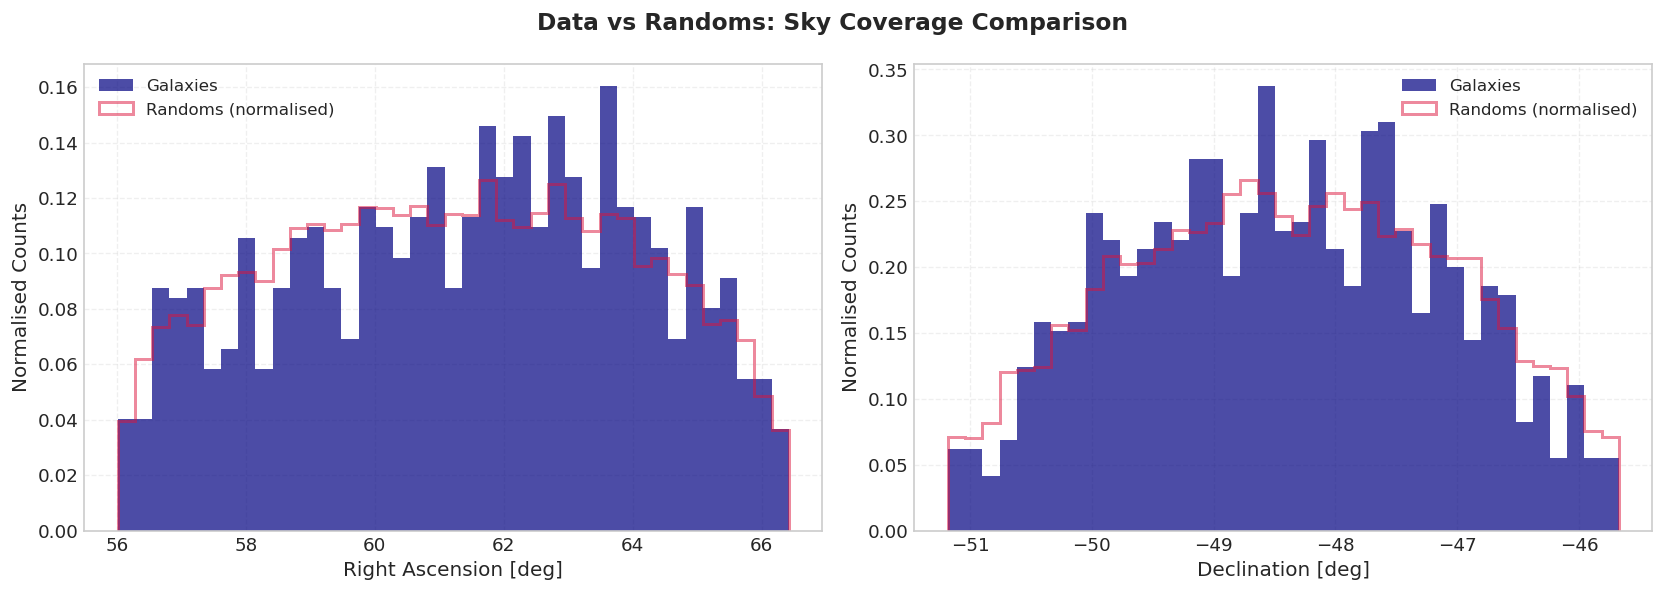

In [4]:
fig, ax = plot_sky_distribution(
    ra, dec, ra_rand=ra_rand, dec_rand=dec_rand,
    title=f"Sky distribution — {SAMPLE.replace('_', ' ')}",
)
plt.show()

fig, axes = plot_data_vs_randoms_density(
    ra, dec, ra_rand, dec_rand,
    n_rand_ratio=cfg["randoms"]["n_randoms_factor"],
)
plt.show()

## 4. Compute the 2PACF

In [5]:
bins = cfg["bins"]

# Check if pre-computed result exists
corr_path = resolve_path(cfg["paths"]["corr_dir"]) / f"2pacf_{SAMPLE}.npz"

if corr_path.exists():
    result = CorrelationResult.load(str(corr_path))
    print(f"Loaded pre-computed 2PACF: {corr_path.name}")
else:
    print(f"Computing 2PACF ({bins['nbins']} bins, {bins['min_sep']}°–{bins['max_sep']}°) …")
    result = compute_2pacf(
        ra, dec, ra_rand, dec_rand,
        min_sep=bins["min_sep"],
        max_sep=bins["max_sep"],
        nbins=bins["nbins"],
        sep_units=bins["sep_units"],
        bin_slop=bins["bin_slop"],
    )
    corr_path.parent.mkdir(parents=True, exist_ok=True)
    result.save(str(corr_path))
    print(f"Saved → {corr_path}")

Loaded pre-computed 2PACF: 2pacf_edf_s_irac_footprint.npz


## 5. Results table

In [6]:
print(f"{'θ [arcmin]':>12}  {'w(θ)':>12}  {'σ_Poisson':>12}  {'DD pairs':>10}  {'Note':>15}")
print("-" * 65)
for i in range(len(result.theta_arcmin)):
    w   = result.w[i]
    err = result.w_err_poisson[i]
    neg = "← negative" if np.isfinite(w) and w < 0 else ""
    print(f"{result.theta_arcmin[i]:12.3f}  {w:12.5f}  {err:12.5f}  "
          f"{result.DD[i]:10.0f}  {neg}")

  θ [arcmin]          w(θ)     σ_Poisson    DD pairs             Note
-----------------------------------------------------------------
       0.668       0.14493       0.40443           7  
       1.004       0.08346       0.26876          15  
       1.505      -0.08252       0.18434          27  ← negative
       2.196       0.42254       0.12643          89  
       3.236       0.12706       0.08668         150  
       4.820       0.22224       0.05835         359  
       7.200       0.11121       0.03929         720  
      10.581       0.12052       0.02636        1612  
      15.675       0.05016       0.01786        3291  
      23.347       0.03967       0.01214        7059  
      34.452       0.02578       0.00836       14670  
      51.088       0.02699       0.00583       30207  
      75.579       0.02532       0.00417       58868  
     111.395       0.00081       0.00314      101736  
     163.416      -0.00854       0.00266      140337  ← negative


## 6. Main 2PACF plot with power-law fit

Negative bins are physically meaningful (anti-correlation at large scales) and are
plotted but excluded from the power-law fit (log-space fitting requires $w > 0$).

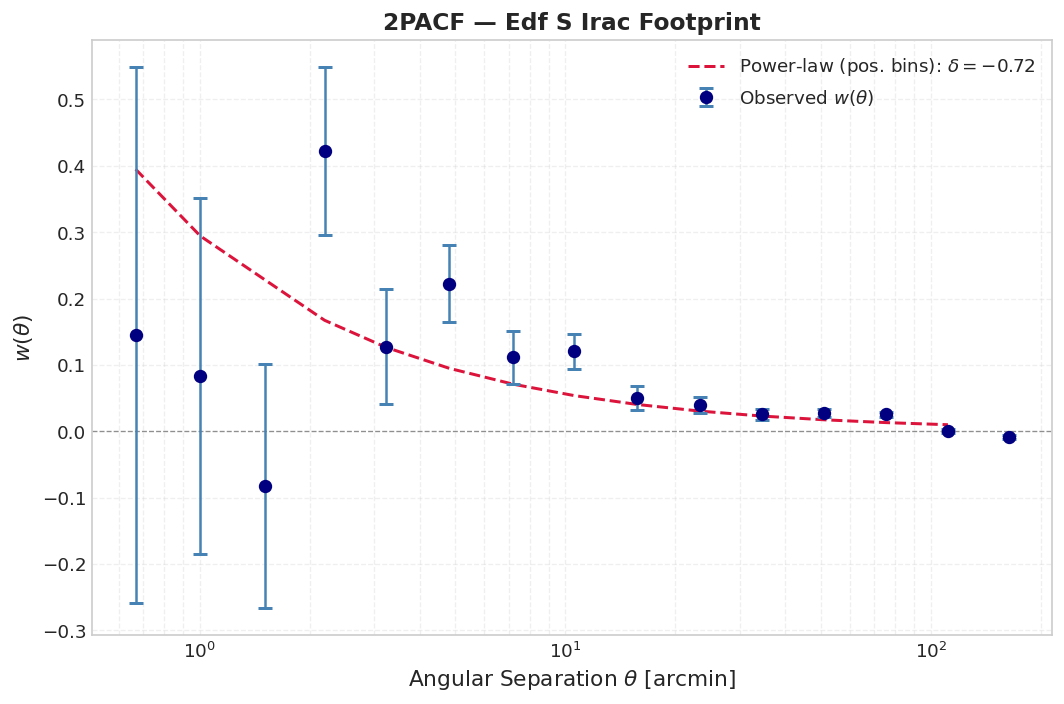

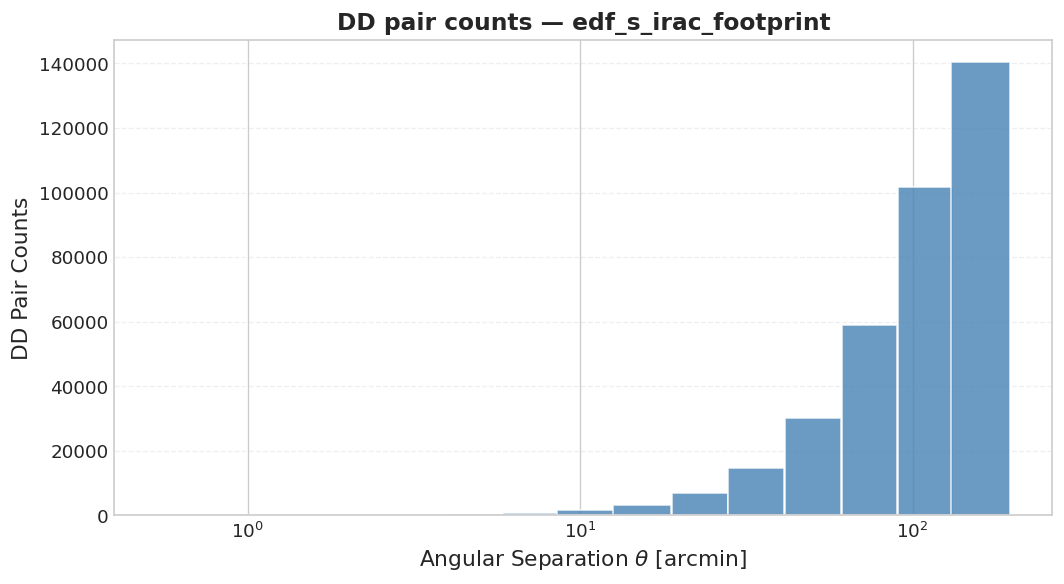

In [7]:
from src.plotting import plot_separation_histogram

fig, ax = plot_2pacf(
    result,
    title=f"2PACF — {SAMPLE.replace('_', ' ').title()}",
    label="Observed $w(\\theta)$",
    fit_powerlaw=True,
)
plt.show()

fig, ax = plot_separation_histogram(
    result.DD, result.theta_arcmin,
    title=f"DD pair counts — {SAMPLE}",
)
plt.show()

## Summary

The IRAC-footprint masked sample shows a positive correlation signal on small angular
scales, turning negative at large separations where the Landy-Szalay estimator is
subject to integral constraint bias. The power-law amplitude and slope are reported
in the fit legend above.

Proceed to **04_2pacf_irac_detected** for the smaller IRAC-detected sub-sample.